In [76]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression

In [77]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [78]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [79]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [80]:
# New feature: FamilySize = SibSp + Parch + 1 (+1 includes the passenger themselves)
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
test["FamilySize"] = test["SibSp"] + test["Parch"] + 1

train[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [81]:
# Feature: "travels alone" — 1 if the passenger has no relatives aboard
train["IsAlone"] = (train["FamilySize"] == 1).astype(int)
test["IsAlone"] = (test["FamilySize"] == 1).astype(int)

train[["FamilySize", "IsAlone"]].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


In [82]:
# Feature: Title extracted from Name (e.g. "Braund, Mr. Owen Harris" -> "Mr")
# The title sits between the comma and the dot: ", Mr."
train["Title"] = train["Name"].str.extract(r",\s*([^.]+)\.", expand=False)
test["Title"] = test["Name"].str.extract(r",\s*([^.]+)\.", expand=False)

# Group the many rare titles into the main buckets
title_map = {
    "Mlle": "Miss", "Ms": "Miss",      # French/alt forms of Miss
    "Mme": "Mrs",                        # French form of Mrs
}
train["Title"] = train["Title"].replace(title_map)
test["Title"] = test["Title"].replace(title_map)

# Anything that isn't Mr / Mrs / Miss / Master -> "Rare" (Dr, Rev, Col, Don, etc.)
common = ["Mr", "Mrs", "Miss", "Master"]
train.loc[~train["Title"].isin(common), "Title"] = "Rare"
test.loc[~test["Title"].isin(common), "Title"] = "Rare"

train["Title"].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [83]:

age_by_title = train.groupby("Title")["Age"].median()
print(age_by_title)

train["Age"] = train["Age"].fillna(train["Title"].map(age_by_title))
test["Age"]  = test["Age"].fillna(test["Title"].map(age_by_title))

# sanity check: no missing Age left
print("\nMissing Age -> train:", train["Age"].isna().sum(), "| test:", test["Age"].isna().sum())

Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64

Missing Age -> train: 0 | test: 0


In [84]:
# Encode categorical columns as numbers

# --- Sex: male -> 0, female -> 1 ---
sex_map = {"male": 0, "female": 1}
train["Sex"] = train["Sex"].map(sex_map)
test["Sex"]  = test["Sex"].map(sex_map)

# --- Embarked: fill the 2 missing with the most common port, then S->0, C->1, Q->2 ---
top_port = train["Embarked"].mode()[0]          # 'S'
train["Embarked"] = train["Embarked"].fillna(top_port)
test["Embarked"]  = test["Embarked"].fillna(top_port)

embarked_map = {"S": 0, "C": 1, "Q": 2}
train["Embarked"] = train["Embarked"].map(embarked_map)
test["Embarked"]  = test["Embarked"].map(embarked_map)

# --- Pclass: already numeric (1 / 2 / 3), nothing to encode ---

train[["Sex", "Pclass", "Embarked"]].head()

,Sex,Pclass,Embarked
0,0,3,0
1,1,1,1
2,1,3,0
3,1,1,0
4,0,3,0


In [85]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0,1,1,Mr


In [86]:
# Fare: добавляем как признак. В test одно значение пропущено -> заполняем медианой train.
test["Fare"] = test["Fare"].fillna(train["Fare"].median())

features = ["Pclass", "Sex", "Age", "Fare", "Embarked", "FamilySize", "IsAlone", "Title"]

# Title ещё текстовый -> one-hot кодирование. drop_first убирает одну колонку (базовая категория).
X      = pd.get_dummies(train[features], columns=["Title"], drop_first=True)
X_test = pd.get_dummies(test[features],  columns=["Title"], drop_first=True)

# Выравниваем колонки: в test может не оказаться какой-то категории Title.
X_test = X_test.reindex(columns=X.columns, fill_value=0)

y = train["Survived"]

X.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,0,22.0,7.2500,0,2,0,False,True,False,False
1,1,1,38.0,71.2833,1,2,0,False,False,True,False
2,3,1,26.0,7.9250,0,1,1,True,False,False,False
3,1,1,35.0,53.1000,0,2,0,False,False,True,False
4,3,0,35.0,8.0500,0,1,1,False,True,False,False


In [87]:
# training
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Делим train на обучение и валидацию 
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_tr, y_tr)

val_pred = model.predict(X_val)
print("accuracy @ 0.5:", accuracy_score(y_val, (val_pred > 0.5).astype(int)))

accuracy @ 0.5: 0.8212290502793296


In [88]:

thresholds = np.arange(0.30, 0.71, 0.01)
accs = [accuracy_score(y_val, (val_pred > t).astype(int)) for t in thresholds]

best_t = thresholds[int(np.argmax(accs))]
print(f"Лучший порог = {best_t:.2f}  ->  accuracy = {max(accs):.4f}")

# Несколько точек для наглядности
for t in np.arange(0.30, 0.71, 0.05):
    print(f"  threshold={t:.2f} -> accuracy={accuracy_score(y_val, (val_pred > t).astype(int)):.4f}")

Лучший порог = 0.34  ->  accuracy = 0.8324
  threshold=0.30 -> accuracy=0.8045
  threshold=0.35 -> accuracy=0.8101
  threshold=0.40 -> accuracy=0.8101
  threshold=0.45 -> accuracy=0.8101
  threshold=0.50 -> accuracy=0.8212
  threshold=0.55 -> accuracy=0.8212
  threshold=0.60 -> accuracy=0.8156
  threshold=0.65 -> accuracy=0.8045
  threshold=0.70 -> accuracy=0.7542


In [92]:
final_model = LinearRegression()
final_model.fit(X, y)

# test_pred = (final_model.predict(X_test) > best_t).astype(int)
test_pred = (final_model.predict(X_test) > 0.5).astype(int)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_pred,
})
submission.to_csv("submission.csv", index=False)

print("submission.csv:", submission.shape)   # ожидаем (418, 2)
submission.head()

submission.csv: (418, 2)


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [90]:
submission.head(20)

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


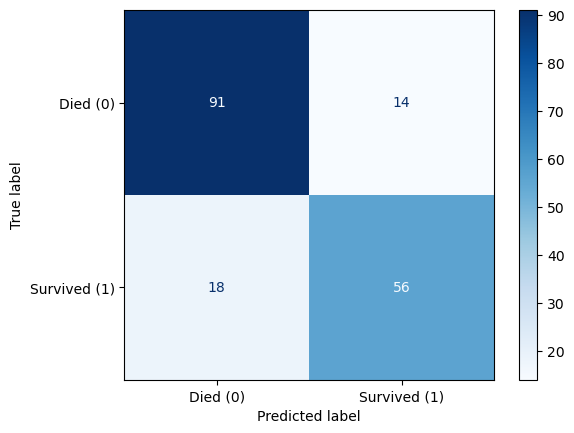

In [95]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# val_pred_labels = (model.predict(X_val) > best_t).astype(int)
val_pred_labels = (model.predict(X_val) > 0.5).astype(int)

cm = confusion_matrix(y_val, val_pred_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died (0)", "Survived (1)"])
disp.plot(cmap="Blues")

plt.show()

In [75]:
# Версия 2: GradientBoostingClassifier + честная кросс-валидация
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

clf = GradientBoostingClassifier(random_state=42)

# 5-кратная кросс-валидация на train -- честная оценка точности
cv_scores = cross_val_score(clf, X, y, cv=5)
print(f"v2 GradientBoosting CV accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# Обучаем на всём train и предсказываем настоящий тест Kaggle
clf.fit(X, y)
test_pred_v2 = clf.predict(X_test)   # классификатор сам выдаёт 0/1, порог не нужен

submission_v2 = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_pred_v2,
})
submission_v2.to_csv("submission_v2.csv", index=False)

print("submission_v2.csv:", submission_v2.shape)   # ожидаем (418, 2)
submission_v2.head()

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Anaconda2026\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Anaconda2026\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Anaconda2026\Lib\site-packages\sklearn\ensemble\_gb.py", line 658, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<4 lines>...
        multi_output=True,
        ^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Anaconda2026\Lib\site-packages\sklearn\utils